In [148]:
import os
import csv
import ast
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, str(Path("..").resolve()))
from utils import savefig

plt.rcParams['font.size'] = 14

save_fig = False

In [149]:
gamma_names = ["0", "02", "04", "06", "08", "10"]
temporal_discount_factors = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
noise_levels = [0, 0.2, 0.4, 0.6, 0.8, 1]
noise_names = ["0", "02", "04", "06", "08", "1"]

In [150]:
df = pd.read_pickle("../data/df_models.pkl")
df_reservoir = pd.read_pickle("../data/df_reservoir.pkl")
df_tcm = pd.read_pickle("../data/df_tcm.pkl")
df_perf = pd.read_pickle("../data/df_perf.pkl")
df_perf_nonoise = pd.read_pickle("../data/df_perf_nonoise.pkl")

### clustering

In [151]:
# df_for_clustering = df[(df["accuracy"] > 0.7) & (df["temporal_factor"] >= 0.5) & ((df["temporal_discount_factor"] > 0.8) | (df["noise_level"] > 0.8)) & (df["wm_noise"] >= 0.04)]
# df_for_clustering = df[(df["accuracy"] > 0.6) & (df["temporal_factor"] >= 0.5) & (df["wm_noise"] >= 0.1)]
df_for_clustering = df[(df["accuracy"] >= 0.6) & (df["temporal_factor"] >= 0.5) & (df["item_decoding_accuracy"] >= 0.6) & (df["wm_noise"] >= 0.04)].copy()
print(len(df_for_clustering))

618


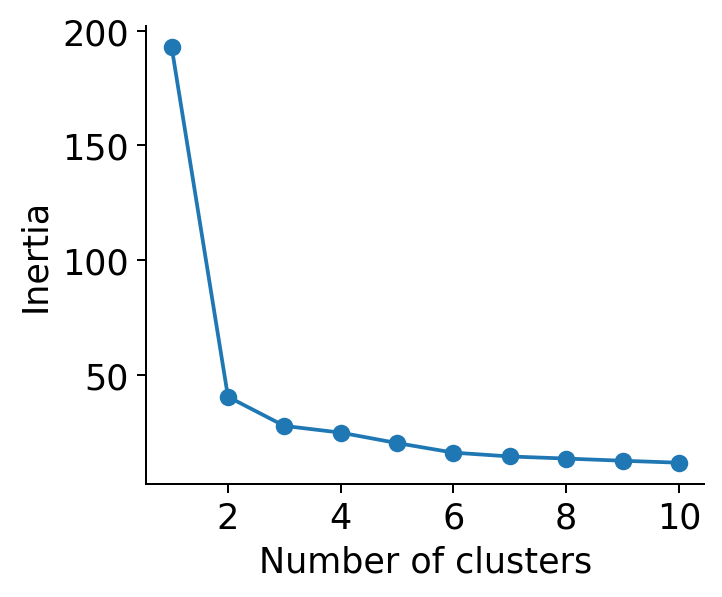

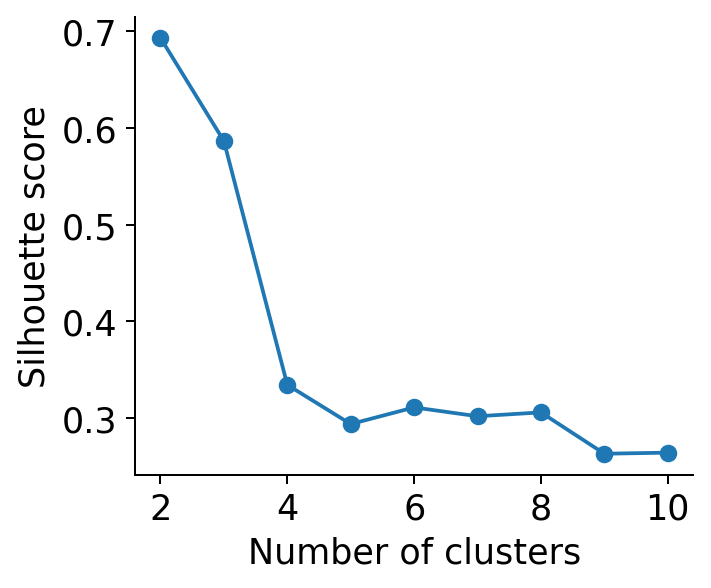

In [152]:
""" test best number of clusters """

from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer, PowerTransformer, normalize
from sklearn.cluster import KMeans  
from sklearn.metrics import silhouette_score

features = ["forward_asymmetry", "temporal_factor",
            "index_decoding_accuracy", "item_decoding_accuracy", "last_item_decoding_accuracy",
            "explained_variance_index", "explained_variance_identity", 
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity",
            # "item_invariance_cross_phase_accuracy_last", "time_invariance_cross_phase_accuracy_last"
            ]

X = df_for_clustering[features]

# scaler = StandardScaler()
# scaler = MinMaxScaler()
# X_normalized = scaler.fit_transform(X)
# X_normalized = normalize(X, norm='l1')
X_normalized = X

# Determine the optimal number of clusters with elbow method
inertia = []
silhoutte_score = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_normalized)
    labels = kmeans.labels_
    inertia.append(kmeans.inertia_)
    if n_clusters > 1:
        silhoutte_score.append(silhouette_score(X_normalized, labels))

plt.figure(figsize=(4, 3.3), dpi=180)
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.title('Inertia for Optimal Number of Clusters')
plt.show()

plt.figure(figsize=(4, 3.3), dpi=180)
plt.plot(range(2, 11), silhoutte_score, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [153]:
""" cluster based on the chosen number of clusters """
# make the optimal number of clusters\

# Fit the KMeans model with the optimal number of clusters
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_normalized)
df_for_clustering["cluster"] = cluster_labels

# Add silhouette score to evaluate clustering quality
silhouette_avg = silhouette_score(X_normalized, cluster_labels)
print(f'Silhouette Score for {optimal_clusters} clusters: {silhouette_avg}')



Silhouette Score for 3 clusters: 0.5866044762688564


In [154]:
# print number of items for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}: {len(df_for_clustering[df_for_clustering["cluster"] == i])} items')
# print 5 info for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}:')
    print(df_for_clustering[df_for_clustering['cluster'] == i][["temporal_discount_factor", "noise_level", "model_num"]].tail())

Cluster 1: 368 items
Cluster 2: 172 items
Cluster 3: 78 items
Cluster 1:
      temporal_discount_factor  noise_level  model_num
1412                       1.0          0.8         12
1413                       1.0          0.8         13
1414                       1.0          0.8         14
1415                       1.0          0.8         15
1419                       1.0          0.8         19
Cluster 2:
      temporal_discount_factor  noise_level  model_num
1435                       1.0          1.0         15
1436                       1.0          1.0         16
1437                       1.0          1.0         17
1438                       1.0          1.0         18
1439                       1.0          1.0         19
Cluster 3:
      temporal_discount_factor  noise_level  model_num
1392                       1.0          0.6         12
1400                       1.0          0.8          0
1409                       1.0          0.8          9
1416                     

In [155]:
# filter the data for plotting clusters
# df_filtered = df_for_clustering[((df_for_clustering["temporal_discount_factor"] > 0.8) | (df_for_clustering["noise_level"] >  0.8)) & (df_for_clustering["wm_noise"] == 0.1)]
# df_filtered = df_for_clustering[df_for_clustering["wm_noise"] == 0.1]
# df_filtered = df_for_clustering[df_for_clustering["accuracy"] > 0.5]
df_filtered = df_for_clustering[((df_for_clustering["temporal_discount_factor"] > 0.8) | (df_for_clustering["noise_level"] > 0.8))].copy()
# df_filtered = df_for_clustering
print(len(df_filtered))

405


In [156]:
# print number of items for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}: {len(df_filtered[df_filtered["cluster"] == i])} items')
# print 5 info for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}:')
    print(df_filtered[df_filtered['cluster'] == i][["temporal_discount_factor", "noise_level", "model_num"]].tail())

Cluster 1: 155 items
Cluster 2: 172 items
Cluster 3: 78 items
Cluster 1:
      temporal_discount_factor  noise_level  model_num
1412                       1.0          0.8         12
1413                       1.0          0.8         13
1414                       1.0          0.8         14
1415                       1.0          0.8         15
1419                       1.0          0.8         19
Cluster 2:
      temporal_discount_factor  noise_level  model_num
1435                       1.0          1.0         15
1436                       1.0          1.0         16
1437                       1.0          1.0         17
1438                       1.0          1.0         18
1439                       1.0          1.0         19
Cluster 3:
      temporal_discount_factor  noise_level  model_num
1392                       1.0          0.6         12
1400                       1.0          0.8          0
1409                       1.0          0.8          9
1416                     

In [157]:
# change number of clusters
df_filtered["cluster"] = df_filtered["cluster"].replace({0: 1, 1: 0})

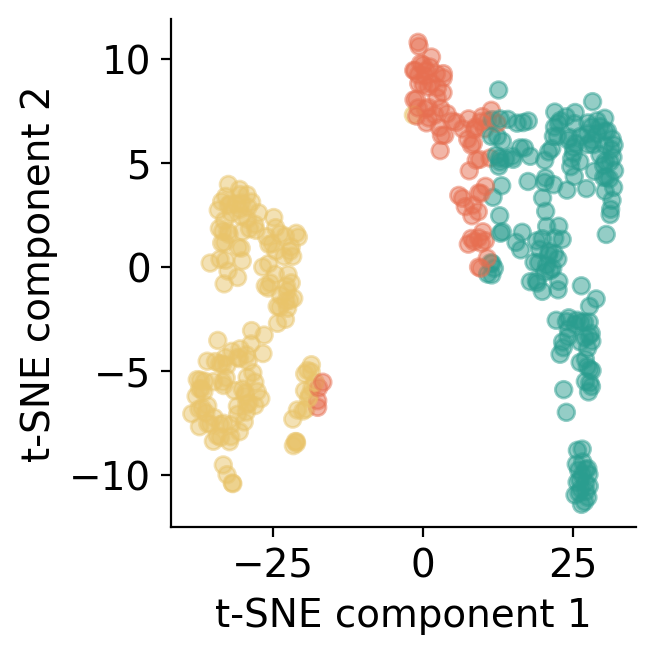

In [158]:
""" t-SNE visualization of clusters """

from sklearn.manifold import TSNE

colormap = np.array(["#2A9D8F", "#E9C46A", "#E76F51", "#F4A261", "#264653"]) 

# patches = [mpatches.Patch(color="#2A9D8F", label="Strategy 1: Memory palace"),
#            mpatches.Patch(color="#E76F51", label="Strategy 2: TCM-like forward"),
#            mpatches.Patch(color="#E9C46A", label="Strategy 3: Backward recall"),
#            mpatches.Patch(color="#264653", label="Reservoir RNN")]

X_tsne = df_filtered[features]

# scaler = StandardScaler()
# scaler = MinMaxScaler()
# X_tsne_normalized = scaler.fit_transform(X_tsne)
X_tsne_normalized = X_tsne
cluster_labels = df_filtered["cluster"]

# Perform t-SNE on the normalized data
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_tsne_normalized)

# Plot the t-SNE results with cluster labels
plt.figure(figsize=(3, 3.3), dpi=200)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colormap[cluster_labels], alpha=0.5)
# plt.title('t-SNE visualization of clusters')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

if save_fig:
    savefig("./figures/fig2", "tsne_clusters", format="svg")


In [159]:
# save data with cluster labels
df_filtered.to_pickle("../data/df_filtered_cluster.pkl")

WCSS Contribution of each dimension:
forward asymmetry: 0.1192
temporal factor: 0.1190
index decoding accuracy: 0.1270
item decoding accuracy: 0.1285
last item decoding accuracy: 0.0905
explained variance index: 0.0904
explained variance identity: 0.0675
cross decoding accuracy index: 0.1266
cross decoding accuracy identity: 0.1314


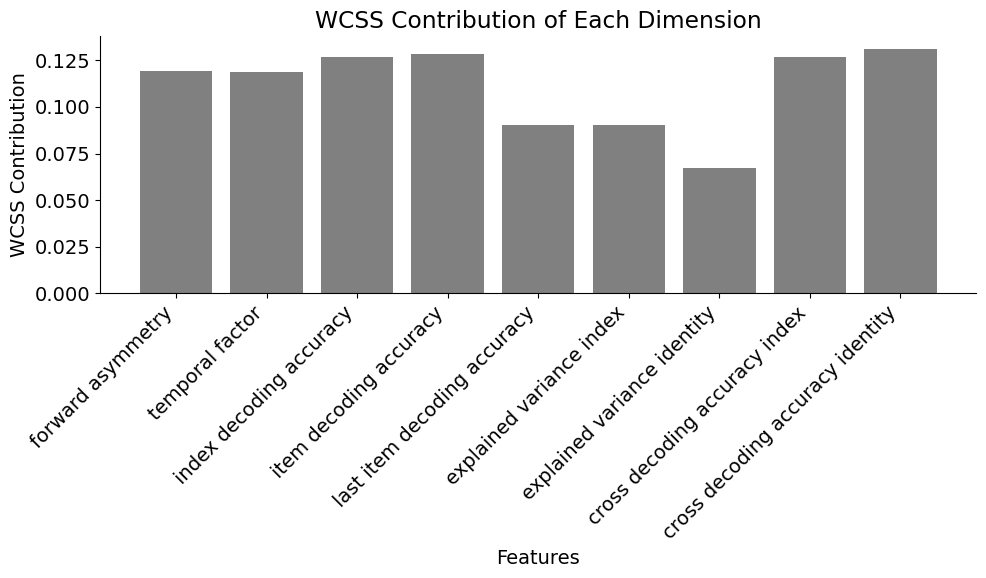

In [160]:
from sklearn.metrics import pairwise_distances_argmin_min
import numpy as np

# Calculate the contribution of each dimension to the clustering
def calculate_wcss_contribution(df, data, features, cluster_centers):
    # Initialize a dictionary to store WCSS contribution for each feature
    wcss_contribution = {feature.replace('_', ' '): 0 for feature in features}
    
    # Iterate over each cluster
    for i in range(optimal_clusters):
        # Get data points in the current cluster
        # cluster_data = df[df['cluster'] == i][features]
        cluster_data = data[df['cluster'] == i]
        
        # Calculate the distance of each point to the cluster center
        _, distances = pairwise_distances_argmin_min(cluster_data, [cluster_centers[i]])
        
        # Calculate the WCSS for each feature
        for j, feature in enumerate(features):
            feature_values = cluster_data[:, j]
            feature_center = cluster_centers[i][j]
            wcss_contribution[feature.replace('_', ' ')] += np.sum((feature_values - feature_center) ** 2)
    
    # Normalize the contributions to sum to 1
    total_wcss = sum(wcss_contribution.values())
    for feature in wcss_contribution:
        wcss_contribution[feature.replace('_', ' ')] /= total_wcss
    
    return wcss_contribution

# Define the features used for clustering
# features = ['forward_asymmetry', 'temporal_factor', 'explained_variance_index', 
#             'explained_variance_identity', 'cross_decoding_accuracy_index', 
#             'cross_decoding_accuracy_identity']

# Assuming cluster_centers is a list of cluster centers obtained from the clustering algorithm
cluster_centers = kmeans.cluster_centers_

X = df_filtered[features]

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Calculate WCSS contribution
wcss_contribution = calculate_wcss_contribution(df_filtered, X_normalized, features, cluster_centers)

# Print the contribution of each dimension
print("WCSS Contribution of each dimension:")
for feature, contribution in wcss_contribution.items():
    print(f"{feature}: {contribution:.4f}")

# Create a bar plot for the WCSS contribution of each dimension
plt.figure(figsize=(10, 6))
plt.bar(wcss_contribution.keys(), wcss_contribution.values(), color='grey')
plt.xlabel('Features')
plt.ylabel('WCSS Contribution')
plt.title('WCSS Contribution of Each Dimension')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



### plot relationship of metrics with clusters

In [161]:
# plot scatter with cluster labels

def plot_scatter_cluster(df, x, y, c, x_label, y_label, fit=True, plot_reservoir=True):
    plt.figure(figsize=(3.4, 3.3), dpi=200)

    plt.scatter(df[x], df[y], c=colormap[df[c].iloc[:]], alpha=0.5)

    if fit:
        if plot_reservoir:
            # plot for reservoir and tcm
            plt.scatter(df_reservoir[x], df_reservoir[y], c=colormap[-1], alpha=0.5)
            # plt.scatter(df_tcm[x], df_tcm[y], c=colormap[-1])
    
        # Reshape x and y for sklearn
        x_reshaped = np.array(df[x]).reshape(-1, 1)
        y_reshaped = np.array(df[y]).reshape(-1, 1)

        # Fit linear regression model
        model = LinearRegression()
        model.fit(x_reshaped, y_reshaped)

        # Predict y values
        sorted_x_idx = np.argsort(x_reshaped.reshape(-1))
        x1, x2 = x_reshaped[sorted_x_idx[0]], x_reshaped[sorted_x_idx[-1]]
        y_pred = model.predict(x_reshaped)
        y1, y2 = y_pred[sorted_x_idx[0]], y_pred[sorted_x_idx[-1]]

        # Calculate R-squared
        r2 = r2_score(y_reshaped, y_pred)
        # Calculate the p-value for the regression
        _, p_value = stats.pearsonr(x_reshaped.flatten(), y_reshaped.flatten())
        
        # Plot the regression line
        plt.plot([x1, x2], [y1, y2], color="grey")

        x_label = x_label+"\n(R² = {:.2f}, p = {:.3f})".format(r2, p_value)

    plt.xlabel(x_label)
    plt.ylabel(y_label)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # plt.tight_layout()
    plt.show()


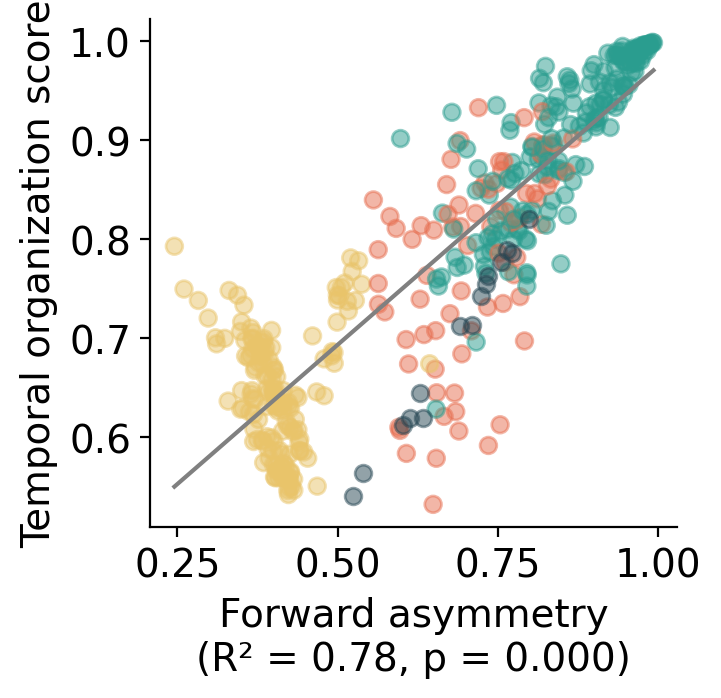

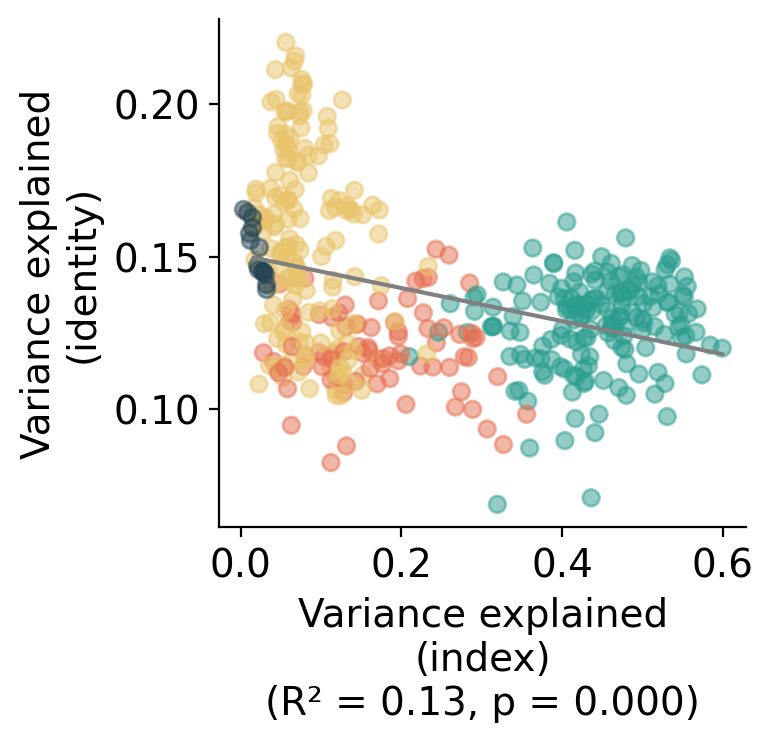

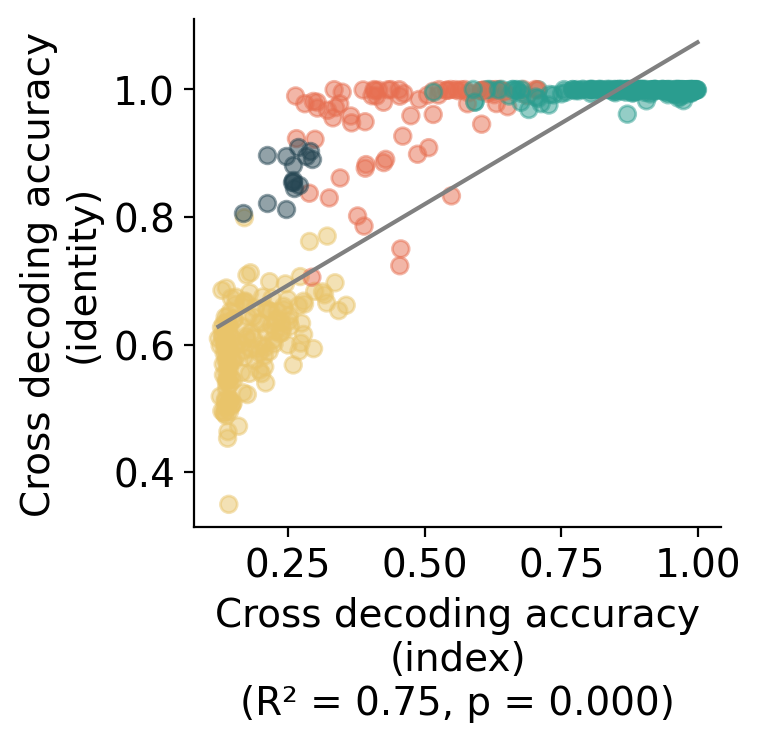

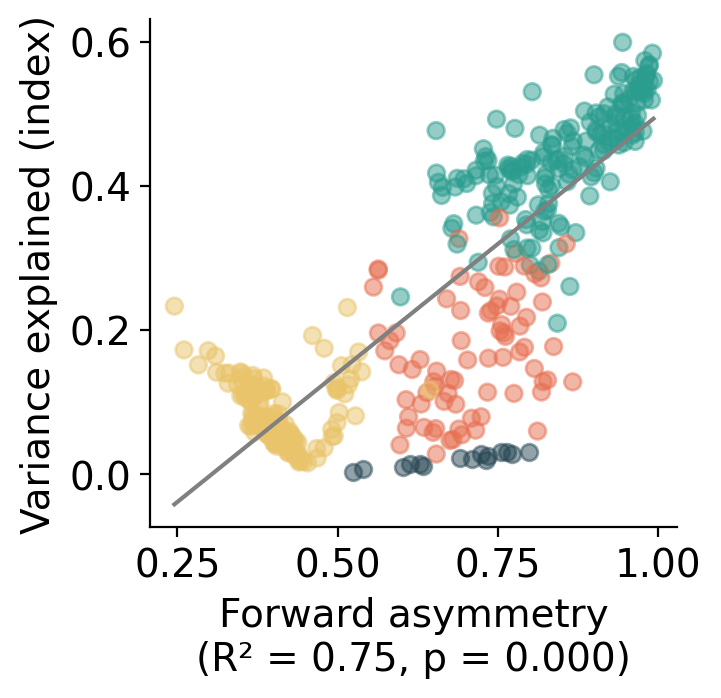

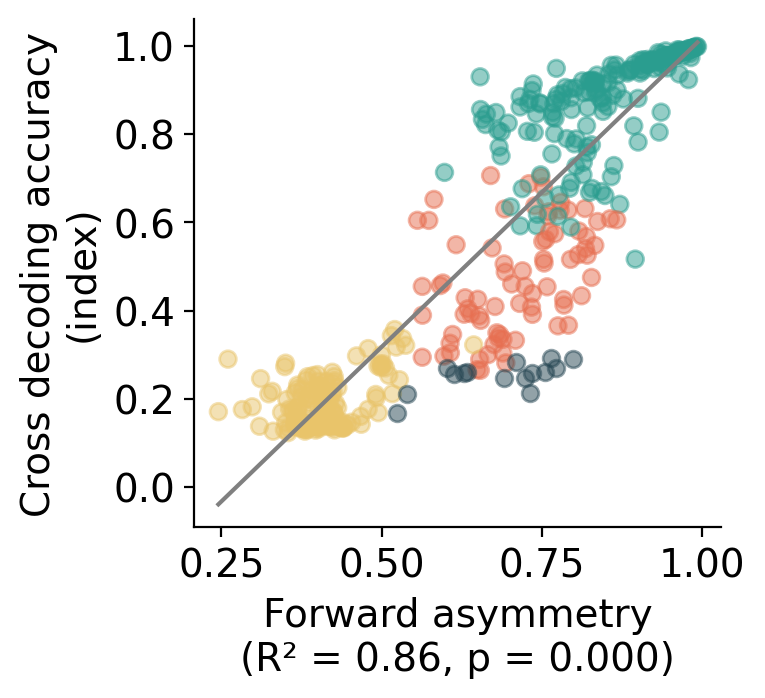

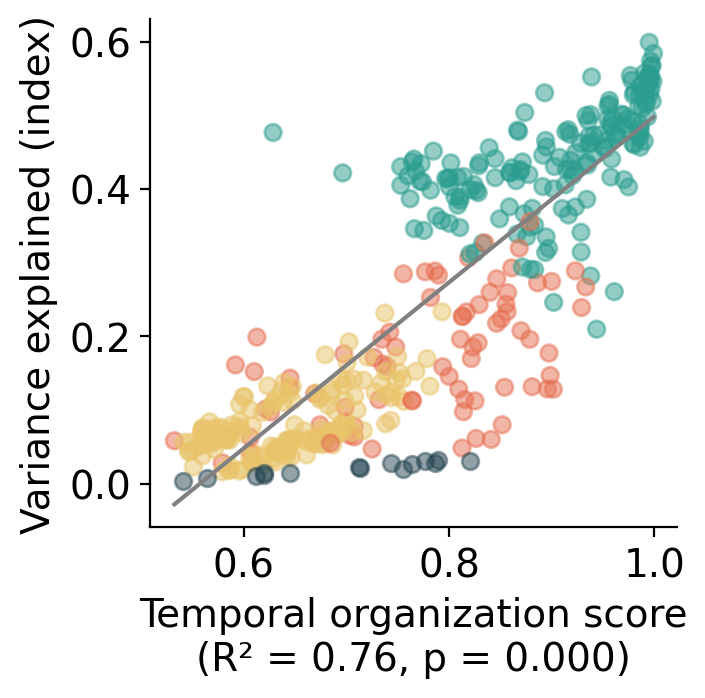

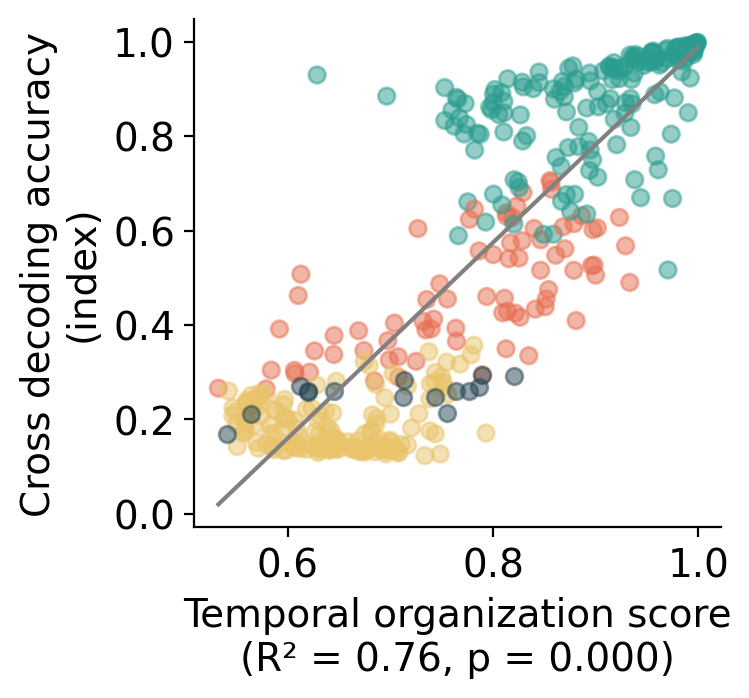

In [162]:
plot_scatter_cluster(df_filtered, 'forward_asymmetry', 'temporal_factor', 'cluster', 'Forward asymmetry', 'Temporal organization score')
plot_scatter_cluster(df_filtered, 'explained_variance_index', 'explained_variance_identity', 'cluster', 'Variance explained\n(index)', 'Variance explained\n(identity)')
plot_scatter_cluster(df_filtered, 'cross_decoding_accuracy_index', 'cross_decoding_accuracy_identity', 'cluster', 'Cross decoding accuracy\n(index)', 'Cross decoding accuracy\n(identity)')

plot_scatter_cluster(df_filtered, 'forward_asymmetry', 'explained_variance_index', 'cluster', 'Forward asymmetry', 'Variance explained (index)')
plot_scatter_cluster(df_filtered, 'forward_asymmetry', 'cross_decoding_accuracy_index', 'cluster', 'Forward asymmetry', 'Cross decoding accuracy\n(index)')

plot_scatter_cluster(df_filtered, 'temporal_factor', 'explained_variance_index', 'cluster', 'Temporal organization score', 'Variance explained (index)')
plot_scatter_cluster(df_filtered, 'temporal_factor', 'cross_decoding_accuracy_index', 'cluster', 'Temporal organization score', 'Cross decoding accuracy\n(index)')


### cluster the performance dataset

In [163]:
from sklearn.cluster import KMeans

features = ["forward_asymmetry", "temporal_factor",
            "index_decoding_accuracy", "item_decoding_accuracy", "last_item_decoding_accuracy",
            "explained_variance_index", "explained_variance_identity", 
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity",
            # "item_invariance_cross_phase_accuracy_last", "time_invariance_cross_phase_accuracy_last"
            ]

# print(df_perf1_filtered.keys())
# print(df_perf2_filtered.keys())


# df_perf1_filtered = df_perf1[(df_perf1["temporal_factor"] >= 0.35)]
# df_perf2_filtered = df_perf2[(df_perf2["temporal_factor"] >= 0.35)]
df_perf_filtered = df_perf_nonoise.copy()

X_perf = df_perf_filtered[features]

# X_perf_normalized = scaler.transform(X_perf)
X_perf_normalized = X_perf

cluster_labels_perf = kmeans.predict(X_perf_normalized)

df_perf_filtered["cluster"] = cluster_labels_perf
df_perf_filtered["cluster"] = df_perf_filtered["cluster"].replace({0: 1, 1: 0})

print(cluster_labels_perf)

print(df_perf_filtered["cluster"].value_counts())






[0 0 2 2 0 0 2 1 1 2 2 1 0 2 2 2 0 0 1 0 2 2 0 2 2 1 1 0 1 0 2 2 1 1 0 2 1
 1 2 1 1 0 0 0 2 1 2 1 2 0 1 0 1 1 1 0 2 2 1 2 0 1 0 1 1 1 0 1 2 0 0 2 2 1
 2 0 0 2 1 1 1 2 0 0 2 1 2 2 1 2 1 1 0 2 1 1 2 0 2 0]
cluster
2    35
0    35
1    30
Name: count, dtype: int64


In [164]:
df_perf_filtered.to_pickle("../data/df_perf_cluster.pkl")

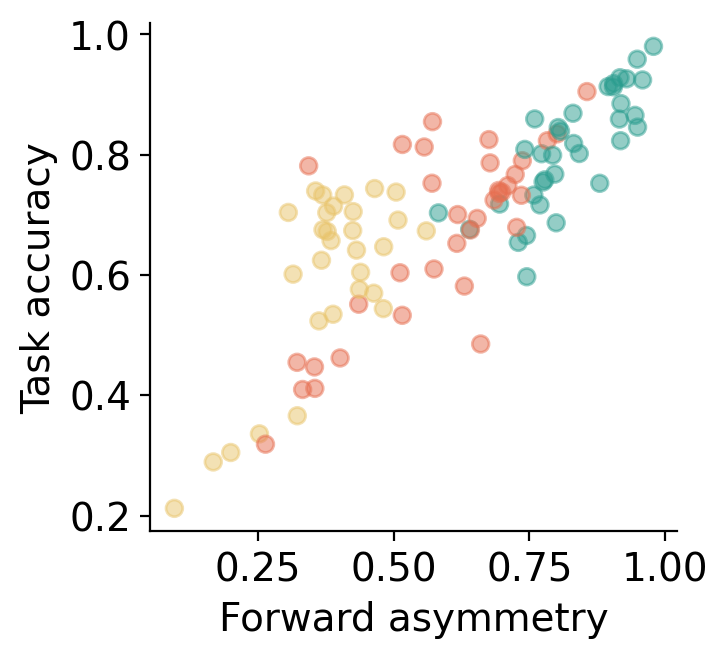

In [165]:
plot_scatter_cluster(df_perf_filtered, 'forward_asymmetry', 'accuracy', 'cluster', 'Forward asymmetry', 'Task accuracy', fit=False)

### cluster for all data

In [166]:
X_all = df[features]
X_all_normalized = X_all

cluster_labels = kmeans.predict(X_all_normalized)

df["cluster"] = cluster_labels

print(df["cluster"].value_counts())



cluster
0    1765
1     254
2     141
Name: count, dtype: int64


In [167]:
# change number of clusters
df["cluster"] = df["cluster"].replace({0: 1, 1: 0})

In [168]:
df.to_pickle("../data/df_cluster.pkl")